In [1]:
import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, Dataset

from glob import glob
from scipy.io import wavfile
from IPython.display import Audio, display

from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler


SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

In [2]:
DATA_DIR = "Final Project Data/genres_original"
file_paths = glob(os.path.join(DATA_DIR, "*", "*.wav"))

rows =[]
for path in file_paths:
    if(path != "Final Project Data/genres_original/jazz/jazz.00054.wav"):
        genre = path[path.rfind("/") + 1 : path.find(".")]
        song_id = path[path.rfind("/") + 1 :].replace(".wav", "")
        rows.append({"path": path, "genre": genre, "song_id": song_id})
df = pd.DataFrame(rows).sort_values(["genre", "song_id"]).reset_index(drop=True)
df

,path,genre,song_id
0,Final Project Data/genres_original/blues/blues...,blues,blues.00000
1,Final Project Data/genres_original/blues/blues...,blues,blues.00001
2,Final Project Data/genres_original/blues/blues...,blues,blues.00002
3,Final Project Data/genres_original/blues/blues...,blues,blues.00003
4,Final Project Data/genres_original/blues/blues...,blues,blues.00004
...,...,...,...
994,Final Project Data/genres_original/rock/rock.0...,rock,rock.00095
995,Final Project Data/genres_original/rock/rock.0...,rock,rock.00096
996,Final Project Data/genres_original/rock/rock.0...,rock,rock.00097
997,Final Project Data/genres_original/rock/rock.0...,rock,rock.00098


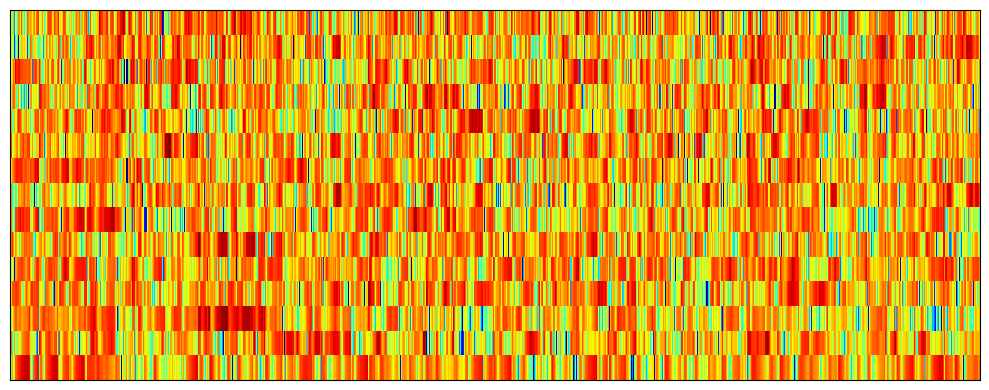

In [3]:
path = df.loc[1, "path"]
y, sr = librosa.load(path, sr=22050, mono=True)

n_mfcc = 15
mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc, n_fft=2048, hop_length=512)
mfcc = (mfcc - mfcc.mean(axis=1, keepdims=True)) / (mfcc.std(axis=1, keepdims=True) + 1e-8)
mfcc_db = librosa.power_to_db(mfcc**2, ref=np.max)

plt.figure(figsize=(10, 4))
librosa.display.specshow(
    mfcc_db,
    sr=sr,
    hop_length=512,
    cmap="jet",     
    vmin=-60,        
    vmax=0,
    y_axis=None               
)
plt.tight_layout()
plt.show()

In [4]:
def create_mfcc_spectrogram(y, sr, out_path):
    n_mfcc = 15
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc, n_fft=2048, hop_length=512)
    mfcc = (mfcc - mfcc.mean(axis=1, keepdims=True)) / (mfcc.std(axis=1, keepdims=True) + 1e-8)
    mfcc_db = librosa.power_to_db(mfcc**2, ref=np.max)

    plt.figure(figsize=(10, 4))
    librosa.display.specshow(
        mfcc_db,
        sr=sr,
        hop_length=512,
        cmap="jet",     
        vmin=-60,        
        vmax=0,
        y_axis=None               
    )
    
    plt.axis("off")
    plt.tight_layout(pad=0)

    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    plt.savefig(out_path, dpi=100, bbox_inches="tight", pad_inches=0)
    plt.close()

In [5]:
le = LabelEncoder()
y = le.fit_transform(df["genre"].values)

X = []
for path, genre in zip(df["path"].values, df["genre"].values):
    y_audio, sr = librosa.load(path, sr=22050, mono=True)
    number = path[path.rfind("0") + 1 :]
    out_path = os.path.join("mfcc_spectograms", genre, f"{number}.png")
    create_mfcc_spectrogram(y_audio, sr, out_path)
    X.append(out_path)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [6]:
import cv2
IMG_SIZE = 128 

def load_images(paths):
    X = []
    for p in paths:
        img = cv2.imread(p)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = img / 255.0
        X.append(img)
    X = np.array(X, dtype=np.float32)
    return torch.tensor(X).permute(0, 3, 1, 2)  # (N,H,W,C) → (N,C,H,W)

X_train_tensor = load_images(X_train).to(DEVICE)
X_test_tensor  = load_images(X_test).to(DEVICE)

y_train_tensor = torch.tensor(y_train, dtype=torch.long).to(DEVICE)
y_test_tensor  = torch.tensor(y_test, dtype=torch.long).to(DEVICE)

In [7]:
class DNNClassifier(nn.Module):
    def __init__(self, in_dim, hidden_dim1=128, hidden_dim2=64, num_classes=10, dropout_p=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim1),     # <-- hidden layer (weights + bias)
            nn.BatchNorm1d(hidden_dim1),        # <-- batch norm (stability/regularization)
            nn.ReLU(),                         # <-- nonlinearity
            nn.Dropout(dropout_p),             # <-- dropout regularization

            nn.Linear(hidden_dim1, hidden_dim2),     # <-- hidden layer (weights + bias)
            nn.BatchNorm1d(hidden_dim2),        # <-- batch norm (stability/regularization)
            nn.ReLU(),                         # <-- nonlinearity
            nn.Dropout(dropout_p),             # <-- dropout regularization

            nn.Linear(hidden_dim2, num_classes)           # <-- output (linear for regression)
        )

    def forward(self, x):
        x = x.reshape(x.size(0), -1)
        return self.net(x)

In [8]:
in_dim = 3 * 128 * 128
num_classes = 10

model = DNNClassifier(
    in_dim=in_dim,
    hidden_dim1=256,
    hidden_dim2=128,
    num_classes=num_classes,
    dropout_p=0.3
).to(DEVICE)

In [9]:
# =========================
# 7) Training loop
# =========================
def train(model, X, y, epochs=50, lr=1e-3, weight_decay=1e-4):
    model.train()
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)  # <-- L2
    loss_fn = nn.CrossEntropyLoss()  

    for epoch in range(1, epochs + 1):
        losses = []

        opt.zero_grad()
        pred = model(X)
        loss = loss_fn(pred, y)
        loss.backward()
        opt.step()

        losses.append(loss.item())

        if epoch in [1, 500, 1000, 1500, 2000]:
            print(f"Epoch {epoch:3d} | train MSE (scaled y): {np.mean(losses):.6f}")

train(model, X_train_tensor, y_train_tensor, epochs=500)

Epoch   1 | train MSE (scaled y): 2.392659
Epoch 500 | train MSE (scaled y): 0.002443


In [10]:
def weighted_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )
    return acc, prec, rec, f1

# ---- DNN predictions ----
model.eval()
with torch.no_grad():
    yhat_tr = model(X_train_tensor.to(DEVICE)).argmax(dim=1).cpu().numpy()
    yhat_te = model(X_test_tensor.to(DEVICE)).argmax(dim=1).cpu().numpy()

tr = weighted_metrics(y_train, yhat_tr)
te = weighted_metrics(y_test,  yhat_te)

# ---- Print like your table ----
out = pd.DataFrame(
    [[ "DNN", *tr, *te ]],
    columns=["Model",
             "Train Acc","Train Prec(w)","Train Rec(w)","Train F1(w)",
             "Test Acc","Test Prec(w)","Test Rec(w)","Test F1(w)"]
)

print("\n=== DNN Results ===")
print(out.to_string(index=False, formatters={c:"{:.4f}".format for c in out.columns if c!="Model"}))


=== DNN Results ===
Model Train Acc Train Prec(w) Train Rec(w) Train F1(w) Test Acc Test Prec(w) Test Rec(w) Test F1(w)
  DNN    0.9987        0.9988       0.9987      0.9987   0.2700       0.3058      0.2700     0.2728
